# 05. Proyecciones de la red

La red bipartita del punto 4 se colapsa en dos redes de un solo modo: autor-autor y video-video.
Ninguna proyección agrega información nueva; ambas son transformaciones de las 343 parejas
autor-video observadas, por lo que heredan la cobertura parcial de los comentarios recolectados.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

def localizar_salida(nombre):
    candidatos = [Path.cwd() / "salidas" / nombre, Path.cwd() / nombre,
                  Path.cwd().parent / "salidas" / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre}. Ejecute primero 04-contruccion-red-bipartita.ipynb."
    )

TIPOS_ARISTAS = {"author_channel_id": "string", "video_id": "string"}
TIPOS_NODOS = {"raw_id": "string", "channel_id": "string"}

aristas_bip = pd.read_csv(localizar_salida("04_aristas_bipartita.csv"), dtype=TIPOS_ARISTAS)
nodos_bip = pd.read_csv(localizar_salida("04_nodos_bipartita.csv"), dtype=TIPOS_NODOS)

nodos_autor = nodos_bip[nodos_bip["node_type"] == "author"].copy()
nodos_video = nodos_bip[nodos_bip["node_type"] == "video"].copy()
incidencias = aristas_bip[["author_channel_id", "video_id", "weight"]]

print(f"Aristas bipartitas: {len(aristas_bip)}")
print(f"Autores: {len(nodos_autor)} | Videos: {len(nodos_video)}")
print(f"Comentarios reconciliados: {aristas_bip['weight'].sum()}")

Aristas bipartitas: 343
Autores: 332 | Videos: 19
Comentarios reconciliados: 406


## 5.1 Proyección autor-autor

Dos autores se conectan si ambos publicaron al menos un comentario observado en el mismo video.
El peso es el número de videos que comparten, no el número de comentarios. Los pares se tratan
como no ordenados y no se generan lazos.

La arista significa co-participación en el mismo contenido. No implica que los autores se hayan
leído, respondido o conocido: los datos no registran quién respondió a quién.

In [2]:
pares_autor = incidencias.merge(incidencias, on="video_id", suffixes=("_a", "_b"))
pares_autor = pares_autor[pares_autor["author_channel_id_a"] < pares_autor["author_channel_id_b"]]

aristas_aa = (
    pares_autor.groupby(["author_channel_id_a", "author_channel_id_b"], as_index=False)
    .agg(weight=("video_id", "nunique"))
    .rename(columns={"author_channel_id_a": "source", "author_channel_id_b": "target"})
    .sort_values(["weight", "source"], ascending=[False, True], ignore_index=True)
)

etiquetas_autor = nodos_autor.set_index("raw_id")["label"]
aristas_aa["source_label"] = aristas_aa["source"].map(etiquetas_autor)
aristas_aa["target_label"] = aristas_aa["target"].map(etiquetas_autor)

assert (aristas_aa["source"] != aristas_aa["target"]).all()
assert not aristas_aa.duplicated(["source", "target"]).any()
assert aristas_aa["weight"].min() >= 1

print(f"Aristas autor-autor: {len(aristas_aa):,}")
print(f"Peso máximo: {aristas_aa['weight'].max()} videos compartidos")
print(aristas_aa["weight"].value_counts().sort_index().rename_axis("videos compartidos").to_string())
aristas_aa.head(10)

Aristas autor-autor: 10,732
Peso máximo: 2 videos compartidos
videos compartidos
1    10730
2        2


,source,target,weight,source_label,target_label
0,UCbrtvygfRT6QXqWDNrOf-cA,UCvcu1kR8xMYy_I1Ty-2mV2Q,2,@Alejandro00710,@hashojea7348
1,UCpsKOkt5iWTbenzeuq7dsmQ,UCylqlpsh8ENNM1LqgQ1KbxA,2,@inge_vergueta,@Jel.Awesh.M
2,UC-HeUTT6_g-VoiWds2a4H-w,UC-Iul5tDYH_oiAMXQH-KaaQ,1,@JorgeMunoz-gd9et,@AlbertoMancilla-p9h
3,UC-HeUTT6_g-VoiWds2a4H-w,UC0HvfEWozTHbwl_iEmJNvVA,1,@JorgeMunoz-gd9et,@OttoPalencia-b7r
4,UC-HeUTT6_g-VoiWds2a4H-w,UC14qlobYKqD-DO0j6b75lcA,1,@JorgeMunoz-gd9et,@megavision4488
5,UC-HeUTT6_g-VoiWds2a4H-w,UC1NiEdJ7gk6FlDexIalWnGg,1,@JorgeMunoz-gd9et,@BorisTebalán
6,UC-HeUTT6_g-VoiWds2a4H-w,UC3YpzAr7pcdKC7BVFEpYzog,1,@JorgeMunoz-gd9et,@carmenfigueroa1232
7,UC-HeUTT6_g-VoiWds2a4H-w,UC63tFvbQ_hJhGDi2nbjssjw,1,@JorgeMunoz-gd9et,@AbigailRodas-w2r
8,UC-HeUTT6_g-VoiWds2a4H-w,UCEHXl4VvvVpq-_4xC5tsbhg,1,@JorgeMunoz-gd9et,@anibalg47
9,UC-HeUTT6_g-VoiWds2a4H-w,UCFybmWapGvBKcQod7cPPH9w,1,@JorgeMunoz-gd9et,@vitalianochavez8382


In [3]:
G_aa = nx.Graph()
G_aa.add_nodes_from(nodos_autor["raw_id"])
G_aa.add_weighted_edges_from(aristas_aa[["source", "target", "weight"]].itertuples(index=False, name=None))

grado_aa = dict(G_aa.degree())
fuerza_aa = dict(G_aa.degree(weight="weight"))

tabla_nodos_aa = nodos_autor[[
    "raw_id", "label", "handle", "comment_count", "videos_commented", "channels_commented"
]].rename(columns={"raw_id": "author_channel_id"}).copy()
tabla_nodos_aa["node_type"] = "author"
tabla_nodos_aa["degree"] = tabla_nodos_aa["author_channel_id"].map(grado_aa)
tabla_nodos_aa["strength"] = tabla_nodos_aa["author_channel_id"].map(fuerza_aa)
for col in ["comment_count", "videos_commented", "channels_commented", "degree", "strength"]:
    tabla_nodos_aa[col] = tabla_nodos_aa[col].astype("Int64")
tabla_nodos_aa = tabla_nodos_aa.sort_values(
    ["videos_commented", "degree", "comment_count"], ascending=False, ignore_index=True
)

print(f"Nodos autor-autor: {G_aa.number_of_nodes()} | aristas: {G_aa.number_of_edges():,}")
print(f"Autores sin coincidencias: {sum(1 for g in grado_aa.values() if g == 0)}")
tabla_nodos_aa.head(12)

Nodos autor-autor: 332 | aristas: 10,732
Autores sin coincidencias: 4


,author_channel_id,label,handle,comment_count,videos_commented,channels_commented,node_type,degree,strength
0,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,/@inge_vergueta,3,3,1,author,183,184
1,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,/@hashojea7348,4,3,1,author,28,29
2,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,/@Jel.Awesh.M,3,2,1,author,174,175
3,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,/@virgiliogarcia3039,3,2,2,author,145,145
4,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,/@moisesvaldez4043,2,2,2,author,133,133
5,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,2,2,2,author,54,54
6,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,/@josegil3813,2,2,1,author,49,49
7,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,/@franciscoflores3120,2,2,2,author,43,43
8,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,/@Alejandro00710,2,2,1,author,23,24
9,UC5H8ASmMC9WrURmzeB4ySog,@ManuelEdran,/@ManuelEdran,5,1,1,author,127,127


El grado de un autor en esta proyección no mide popularidad propia: mide cuántas personas
comentaron los mismos videos. Un autor que participa en un video muy comentado obtiene grado alto
sin haber interactuado con nadie.

In [4]:
# Cada video aporta una camarilla completa entre sus autores: C(n, 2) aristas.
aporte = nodos_video[["raw_id", "label", "channel_name", "unique_authors"]].copy()
aporte["pares_generados"] = (aporte["unique_authors"] * (aporte["unique_authors"] - 1) / 2).astype(int)
aporte = aporte.sort_values("pares_generados", ascending=False, ignore_index=True)
aporte["proporcion_aristas_aa"] = aporte["pares_generados"] / len(aristas_aa)

print(f"Suma de pares generados por video: {aporte['pares_generados'].sum():,}")
print(f"Aristas únicas observadas: {len(aristas_aa):,} (la diferencia son pares repetidos en dos videos)")
aporte.head(6)

Suma de pares generados por video: 10,734
Aristas únicas observadas: 10,732 (la diferencia son pares repetidos en dos videos)


,raw_id,label,channel_name,unique_authors,pares_generados,proporcion_aristas_aa
0,n8iP75gIpmw,Qué rico come tu diputado,Quorum,128.000,8128,0.757
1,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,49.000,1176,0.110
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,32.000,496,0.046
3,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25.000,300,0.028
4,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,19.000,171,0.016
5,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,Noticias Telemundo,18.000,153,0.014


## 5.2 Proyección video-video

Dos videos se conectan si al menos un autor comentó en ambos. El peso es el número de autores
compartidos. La arista describe audiencia común observada, no similitud temática ni relación entre
los canales que los publicaron.

In [5]:
pares_video = incidencias.merge(incidencias, on="author_channel_id", suffixes=("_a", "_b"))
pares_video = pares_video[pares_video["video_id_a"] < pares_video["video_id_b"]]

aristas_vv = (
    pares_video.groupby(["video_id_a", "video_id_b"], as_index=False)
    .agg(weight=("author_channel_id", "nunique"))
    .rename(columns={"video_id_a": "source", "video_id_b": "target"})
    .sort_values(["weight", "source"], ascending=[False, True], ignore_index=True)
)

titulo_video = nodos_video.set_index("raw_id")["label"]
canal_video = nodos_video.set_index("raw_id")["channel_name"]
aristas_vv["source_title"] = aristas_vv["source"].map(titulo_video)
aristas_vv["target_title"] = aristas_vv["target"].map(titulo_video)
aristas_vv["source_channel"] = aristas_vv["source"].map(canal_video)
aristas_vv["target_channel"] = aristas_vv["target"].map(canal_video)
aristas_vv["mismo_canal"] = aristas_vv["source_channel"] == aristas_vv["target_channel"]

assert (aristas_vv["source"] != aristas_vv["target"]).all()
assert not aristas_vv.duplicated(["source", "target"]).any()

print(f"Aristas video-video: {len(aristas_vv)} | autores compartidos en total: {aristas_vv['weight'].sum()}")
print(f"Aristas dentro del mismo canal: {aristas_vv['mismo_canal'].sum()} de {len(aristas_vv)}")
aristas_vv[["source", "target", "weight", "source_title", "target_title", "mismo_canal"]]

Aristas video-video: 11 | autores compartidos en total: 13
Aristas dentro del mismo canal: 7 de 11


,source,target,weight,source_title,target_title,mismo_canal
0,j43HgwYFKfk,n8iP75gIpmw,2,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,True
1,ndAZjHqzzT8,yLZS3JiEBg8,2,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,True
2,06mFNPU0aB8,6W4u8sGEnGM,1,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Inician los trabajos de recuperación del Puente Belice II.,False
3,6W4u8sGEnGM,PjmxCj-a9Hg,1,Inician los trabajos de recuperación del Puente Belice II.,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,True
4,PjmxCj-a9Hg,n8iP75gIpmw,1,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Qué rico come tu diputado,False
5,WIUZtitfLRw,ndAZjHqzzT8,1,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,True
6,WIUZtitfLRw,yLZS3JiEBg8,1,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,True
7,b_Hkrkl3adA,n8iP75gIpmw,1,Bloqueos en Guatemala este 31 de agosto por alza en combustibles a...,Qué rico come tu diputado,False
8,is3Mk5oC19g,j43HgwYFKfk,1,Capturan a ladrón que había quedado grabado mientras robaba en una...,La cooptación de Walter Mazariegos en la USAC,False
9,j43HgwYFKfk,ndAZjHqzzT8,1,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,True


In [6]:
G_vv = nx.Graph()
G_vv.add_nodes_from(nodos_video["raw_id"])
G_vv.add_weighted_edges_from(aristas_vv[["source", "target", "weight"]].itertuples(index=False, name=None))

grado_vv = dict(G_vv.degree())
fuerza_vv = dict(G_vv.degree(weight="weight"))

tabla_nodos_vv = nodos_video[[
    "raw_id", "label", "channel_id", "channel_name", "category", "view_count",
    "comment_count", "unique_authors"
]].rename(columns={"raw_id": "video_id"}).copy()
tabla_nodos_vv["node_type"] = "video"
tabla_nodos_vv["degree"] = tabla_nodos_vv["video_id"].map(grado_vv)
tabla_nodos_vv["strength"] = tabla_nodos_vv["video_id"].map(fuerza_vv)
for col in ["view_count", "comment_count", "unique_authors", "degree", "strength"]:
    tabla_nodos_vv[col] = tabla_nodos_vv[col].astype("Int64")
tabla_nodos_vv = tabla_nodos_vv.sort_values(["degree", "strength"], ascending=False, ignore_index=True)

print(f"Nodos video-video: {G_vv.number_of_nodes()} | aristas: {G_vv.number_of_edges()}")
print(f"Videos sin audiencia compartida: {sum(1 for g in grado_vv.values() if g == 0)}")
tabla_nodos_vv[["video_id", "label", "channel_name", "unique_authors", "degree", "strength"]]

Nodos video-video: 19 | aristas: 11
Videos sin audiencia compartida: 9


,video_id,label,channel_name,unique_authors,degree,strength
0,n8iP75gIpmw,Qué rico come tu diputado,Quorum,128,4,5
1,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,10,4,5
2,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,49,3,4
3,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,2,3
4,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,32,2,2
5,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,19,2,2
6,WIUZtitfLRw,Caminar en una ciudad hecha para carros,Quorum,6,2,2
7,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Noti7,13,1,1
8,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles a...,PrensaLibreOficial,7,1,1
9,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mientras robaba en una...,TN23 Guatemala,7,1,1


In [7]:
SALIDAS = Path.cwd() / "salidas"
SALIDAS.mkdir(exist_ok=True)
aristas_aa.to_csv(SALIDAS / "05_aristas_autor_autor.csv", index=False)
tabla_nodos_aa.to_csv(SALIDAS / "05_nodos_autor_autor.csv", index=False)
aristas_vv.to_csv(SALIDAS / "05_aristas_video_video.csv", index=False)
tabla_nodos_vv.to_csv(SALIDAS / "05_nodos_video_video.csv", index=False)
print("Tablas de ambas proyecciones exportadas en ./salidas/")

Tablas de ambas proyecciones exportadas en ./salidas/


## 5.3 Comparación de las dos proyecciones

Se contrastan tamaño, densidad y fragmentación. El análisis topológico completo corresponde al
punto 6; aquí solo se comparan las dos vistas.

In [8]:
def resumen_proyeccion(G, nombre):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    grados = [g for _, g in G.degree()]
    pesos = [d["weight"] for _, _, d in G.edges(data=True)]
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    return {
        "proyección": nombre,
        "nodos": n,
        "aristas": m,
        "densidad": nx.density(G),
        "grado medio": float(np.mean(grados)),
        "grado máximo": int(np.max(grados)),
        "nodos aislados": int(sum(1 for g in grados if g == 0)),
        "peso medio": float(np.mean(pesos)) if pesos else 0.0,
        "peso máximo": int(np.max(pesos)) if pesos else 0,
        "componentes": len(componentes),
        "componente mayor": len(componentes[0]),
        "% en componente mayor": 100 * len(componentes[0]) / n,
    }

comparacion = pd.DataFrame([
    resumen_proyeccion(G_aa, "autor-autor"),
    resumen_proyeccion(G_vv, "video-video"),
]).set_index("proyección").T
comparacion

proyección,autor-autor,video-video
nodos,332.000,19.000
aristas,"10,732.000",11.000
densidad,0.195,0.064
grado medio,64.651,1.158
grado máximo,183.000,4.000
nodos aislados,4.000,9.000
peso medio,1.000,1.182
peso máximo,2.000,2.000
componentes,10.000,10.000
componente mayor,276.000,10.000


Qué representa cada una:

La proyección autor-autor describe coincidencia de público. Sus 10,732 aristas provienen de solo 19
videos, porque cada video convierte a todos sus comentaristas en una camarilla completa. El video
con más participación aporta por sí solo alrededor del 76% de las aristas, de modo que la densidad
de 0.195 y el grado medio de 64.6 son en gran parte un artefacto de la proyección y no evidencia de
una comunidad conversacional. El 99.98% de los pares comparte un único video: casi nadie repite
compañía entre contenidos distintos.

La proyección video-video describe circulación de audiencia entre contenidos. Es una red pequeña y
dispersa: 19 videos, 11 aristas y 9 videos aislados. Cada arista corresponde a uno o dos autores
que comentaron en ambos videos, es decir, a evidencia muy delgada. Aun así ordena el material:
7 de sus 11 aristas unen videos del mismo canal y las 4 restantes cruzan canales, señal de que unos
pocos comentaristas circulan entre líneas editoriales distintas.

Ambas redes tienen 10 componentes, las mismas de la red bipartita. Ninguna proyección puede unir
componentes que ya estaban separadas ni distinguir un aislamiento real de un video que simplemente
no recibió cobertura de comentarios en la recolección.

## 5.4 Visualización de las proyecciones

Se muestran todos los nodos y aristas de cada proyección, incluidos los nodos aislados.

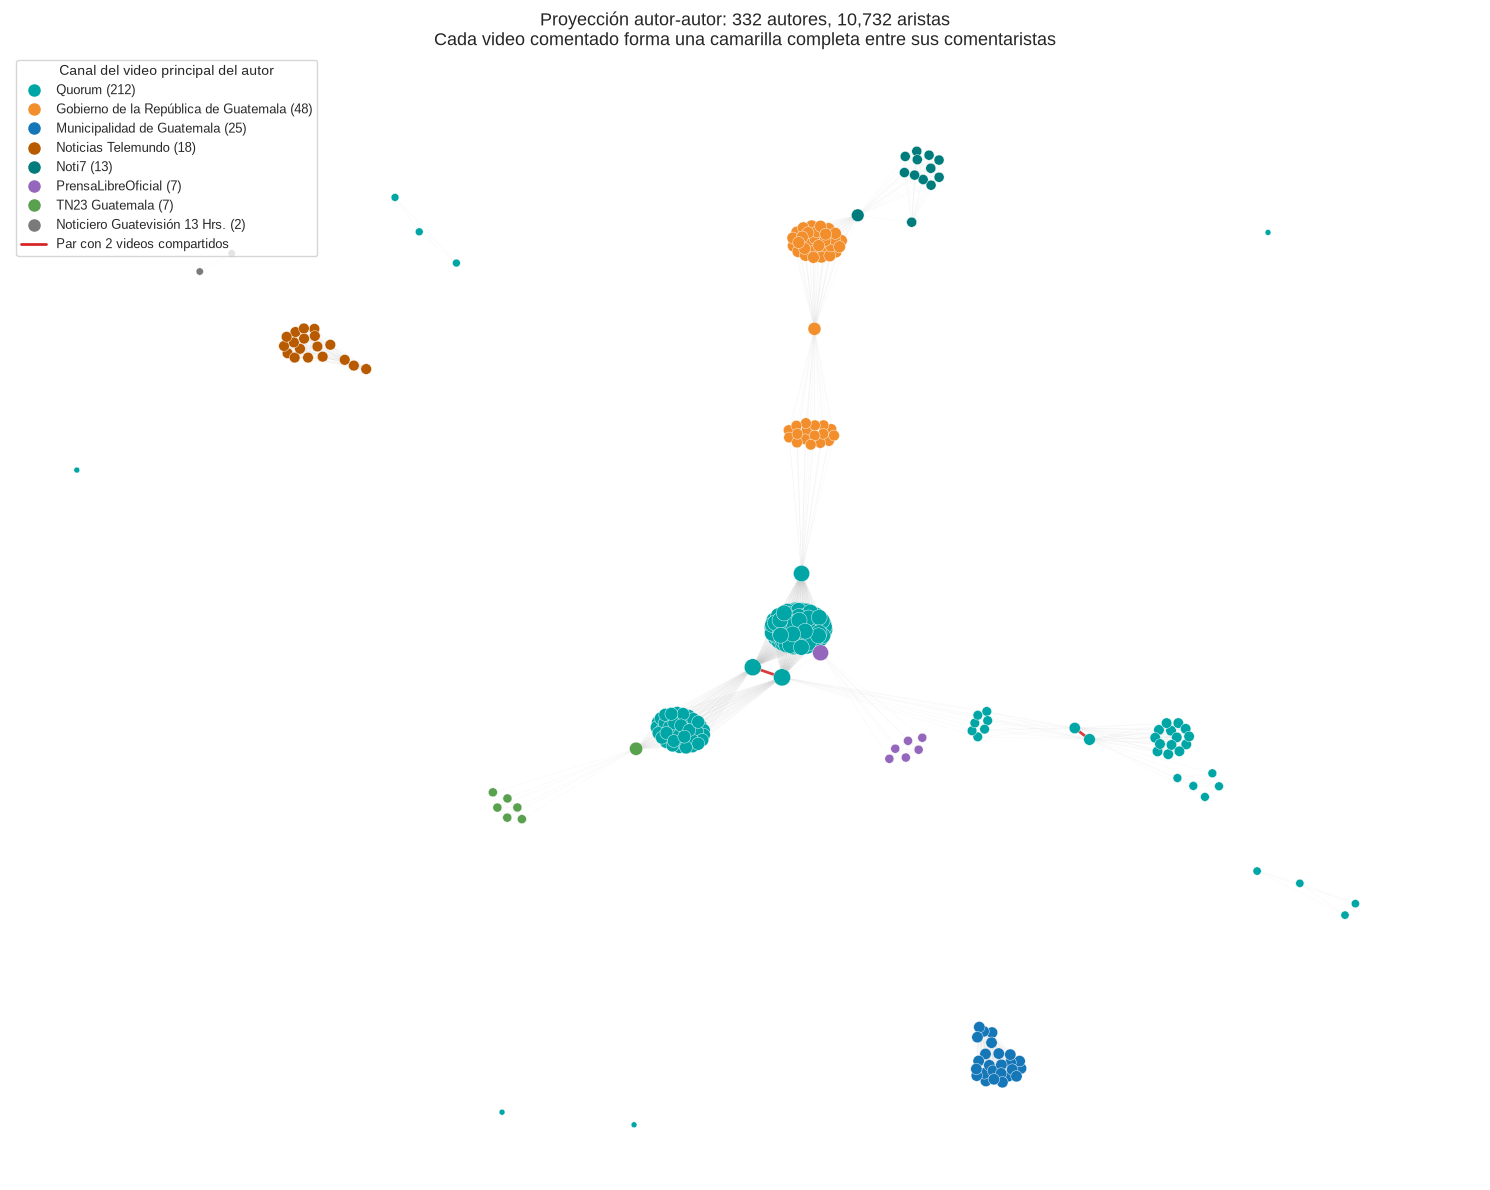

In [9]:
PALETA = ["#00A6A6", "#F28E2B", "#1677B8", "#B85B00", "#007C7C",
          "#9467BD", "#59A14F", "#7A7A7A"]

principal = (aristas_bip.sort_values(["author_channel_id", "weight", "video_id"],
                                     ascending=[True, False, True])
             .drop_duplicates("author_channel_id").set_index("author_channel_id"))
canal_por_autor = principal["video_id"].map(canal_video)
orden_canales = canal_por_autor.value_counts().index.tolist()
color_canal = {canal: PALETA[i % len(PALETA)] for i, canal in enumerate(orden_canales)}

pos_aa = nx.spring_layout(G_aa, weight="weight", k=0.35, iterations=150, seed=7)
nodos_orden = list(G_aa.nodes())
colores = [color_canal.get(canal_por_autor.get(n), "#7A7A7A") for n in nodos_orden]
tamaños = [18 + 10 * grado_aa[n] ** 0.5 for n in nodos_orden]

fig, ax = plt.subplots(figsize=(15, 12))
nx.draw_networkx_edges(G_aa, pos_aa, ax=ax, edge_color="#B0B0B0", alpha=0.08, width=0.4)
compartidos = [(u, v) for u, v, d in G_aa.edges(data=True) if d["weight"] >= 2]
nx.draw_networkx_edges(G_aa, pos_aa, edgelist=compartidos, ax=ax,
                       edge_color="#D62728", alpha=0.9, width=2.0)
nx.draw_networkx_nodes(G_aa, pos_aa, nodelist=nodos_orden, ax=ax, node_size=tamaños,
                       node_color=colores, linewidths=0.3, edgecolors="white")

manejadores = [plt.Line2D([], [], marker="o", linestyle="", markersize=8, color=color_canal[c],
                          label=f"{c} ({int((canal_por_autor == c).sum())})") for c in orden_canales]
manejadores.append(plt.Line2D([], [], color="#D62728", linewidth=2,
                              label="Par con 2 videos compartidos"))
ax.legend(handles=manejadores, loc="upper left", fontsize=9, frameon=True, title="Canal del video principal del autor")
ax.set_title(f"Proyección autor-autor: {G_aa.number_of_nodes()} autores, {G_aa.number_of_edges():,} aristas\n"
             "Cada video comentado forma una camarilla completa entre sus comentaristas", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Las agrupaciones visibles son las camarillas inducidas por cada video, no comunidades de
conversación. Los cuatro autores sin conexiones son quienes comentaron únicamente en videos donde
fueron el único comentarista observado. Las dos aristas rojas son los únicos pares de autores que
coinciden en dos videos.

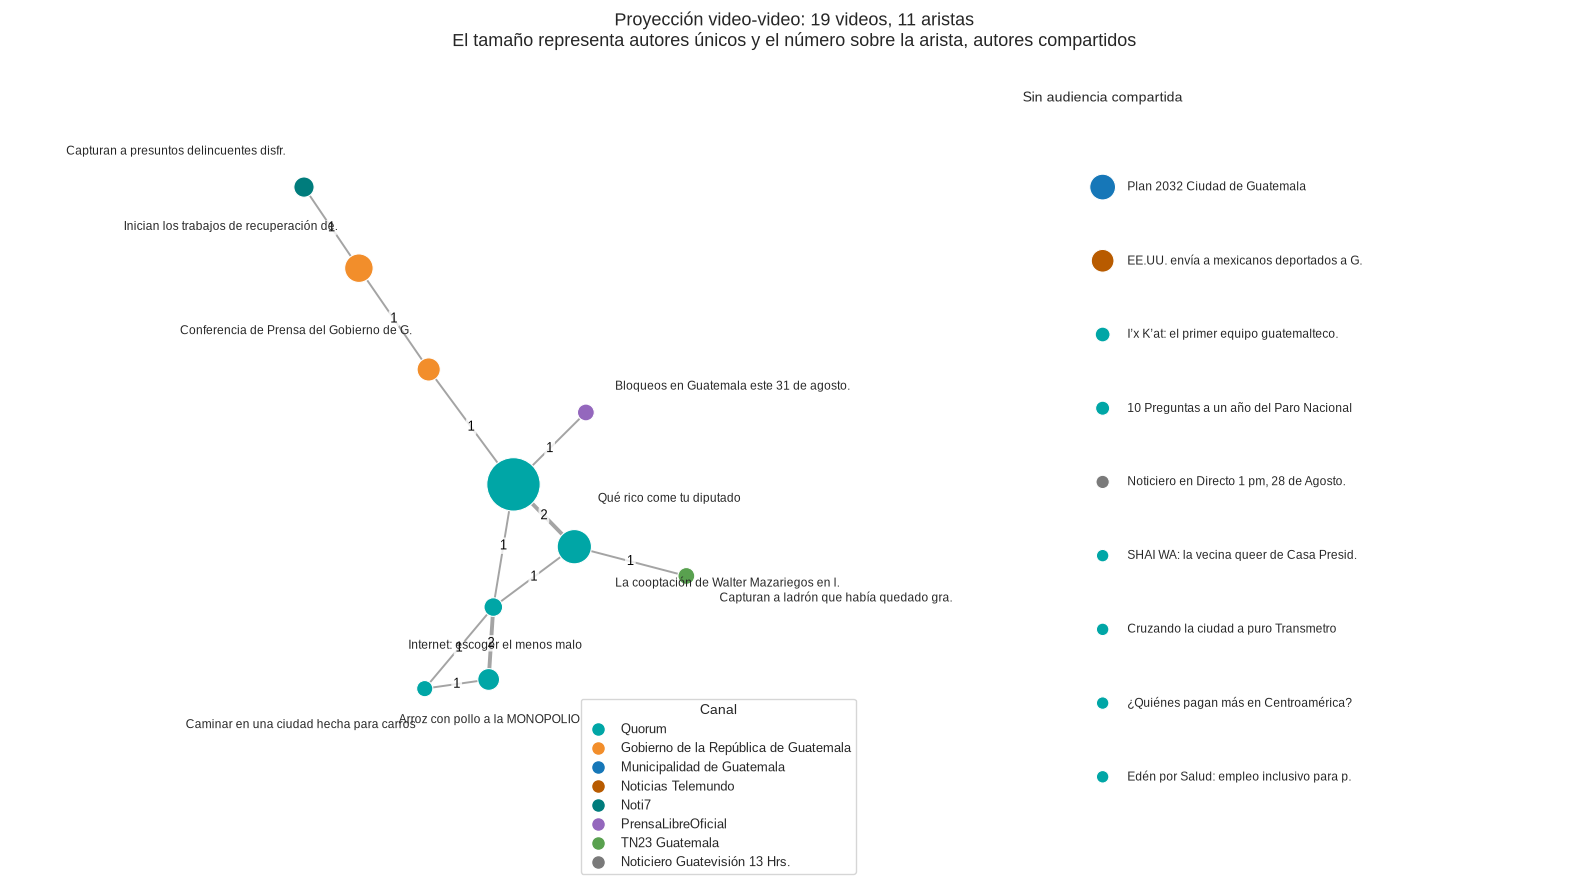

In [10]:
info_vv = tabla_nodos_vv.set_index("video_id")
conectados = [n for n in G_vv.nodes() if G_vv.degree(n) > 0]
aislados = sorted((n for n in G_vv.nodes() if G_vv.degree(n) == 0),
                  key=lambda v: -info_vv.loc[v, "unique_authors"])

# La componente conectada se dispone con spring layout; los aislados se listan aparte
# para que sigan visibles y no dispersen el resto del grafo.
bruto = nx.spring_layout(G_vv.subgraph(conectados), weight="weight", k=1.4, iterations=600, seed=11)
coords = np.array([bruto[n] for n in conectados])
coords = (coords - coords.mean(axis=0)) / np.abs(coords - coords.mean(axis=0)).max()
pos_vv = {n: (0.95 * x, y) for n, (x, y) in zip(conectados, coords)}
for i, n in enumerate(aislados):
    pos_vv[n] = (1.75, 1.0 - 0.25 * i)

def recortar(texto, n=40):
    texto = str(texto)
    return texto if len(texto) <= n else texto[:n - 1] + "."

fig, ax = plt.subplots(figsize=(16, 9))
nx.draw_networkx_edges(G_vv, pos_vv, ax=ax, edge_color="#5A5A5A", alpha=0.55,
                       width=[1.4 * d["weight"] for _, _, d in G_vv.edges(data=True)])
nx.draw_networkx_nodes(
    G_vv, pos_vv, ax=ax, nodelist=list(G_vv.nodes()),
    node_size=[70 + 11 * info_vv.loc[n, "unique_authors"] for n in G_vv.nodes()],
    node_color=[color_canal.get(info_vv.loc[n, "channel_name"], "#7A7A7A") for n in G_vv.nodes()],
    linewidths=0.8, edgecolors="white")
nx.draw_networkx_edge_labels(
    G_vv, pos_vv, ax=ax, font_size=9, rotate=False,
    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    edge_labels={(u, v): d["weight"] for u, v, d in G_vv.edges(data=True)})

# Las etiquetas se alejan del centro del grafo para reducir superposiciones.
centro = np.mean([pos_vv[n] for n in conectados], axis=0)
for n in conectados:
    x, y = pos_vv[n]
    direccion = np.array([x, y]) - centro
    direccion = direccion / (np.linalg.norm(direccion) or 1)
    radio = 0.10 + 0.0011 * info_vv.loc[n, "unique_authors"]
    ax.text(x + radio * direccion[0], y + radio * direccion[1],
            recortar(info_vv.loc[n, "label"]), fontsize=8.5,
            ha="left" if direccion[0] > 0.2 else ("right" if direccion[0] < -0.2 else "center"),
            va="bottom" if direccion[1] >= 0 else "top")
for n in aislados:
    x, y = pos_vv[n]
    ax.text(x + 0.07, y, recortar(info_vv.loc[n, "label"]), fontsize=8.5, ha="left", va="center")
ax.text(1.75, 1.28, "Sin audiencia compartida", fontsize=10, ha="center", va="bottom")

canales_presentes = [c for c in orden_canales if c in set(info_vv["channel_name"])]
manejadores = [plt.Line2D([], [], marker="o", linestyle="", markersize=8, color=color_canal[c], label=c)
               for c in canales_presentes]
ax.legend(handles=manejadores, loc="lower left", bbox_to_anchor=(0.36, 0.0),
          fontsize=9, frameon=True, title="Canal")
ax.set_title(f"Proyección video-video: {G_vv.number_of_nodes()} videos, {G_vv.number_of_edges()} aristas\n"
             "El tamaño representa autores únicos y el número sobre la arista, autores compartidos", fontsize=13)
ax.set_xlim(-1.35, 3.1)
ax.set_ylim(-1.35, 1.45)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Conclusión

La proyección autor-autor produce una red densa y muy agrupada, pero su densidad proviene de la
mecánica de la proyección y de la concentración de comentarios en un solo video. La proyección
video-video muestra que la audiencia compartida entre contenidos es escasa: 9 de 19 videos no
comparten ningún comentarista y las coincidencias existentes se sostienen en uno o dos autores.
Las dos redes describen la misma evidencia desde ángulos distintos y ninguna documenta interacción
directa entre personas.